## MLP using Sklearn

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy

In [2]:
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)

In [3]:
# load pima indians dataset
dataset = numpy.loadtxt("pima-indians-diabetes.csv", delimiter=",")
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
y = dataset[:,8]

In [4]:
# train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

In [5]:
#Normalization

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10),max_iter=1000, verbose=2)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.97322078
Iteration 2, loss = 0.95988981
Iteration 3, loss = 0.94696938
Iteration 4, loss = 0.93513825
Iteration 5, loss = 0.92364982
Iteration 6, loss = 0.91253170
Iteration 7, loss = 0.90252676
Iteration 8, loss = 0.89203360
Iteration 9, loss = 0.88301304
Iteration 10, loss = 0.87440040
Iteration 11, loss = 0.86560356
Iteration 12, loss = 0.85744149
Iteration 13, loss = 0.84999216
Iteration 14, loss = 0.84251866
Iteration 15, loss = 0.83473714
Iteration 16, loss = 0.82785462
Iteration 17, loss = 0.82033614
Iteration 18, loss = 0.81305501
Iteration 19, loss = 0.80620462
Iteration 20, loss = 0.79849013
Iteration 21, loss = 0.79150308
Iteration 22, loss = 0.78417821
Iteration 23, loss = 0.77650951
Iteration 24, loss = 0.76918459
Iteration 25, loss = 0.76178319
Iteration 26, loss = 0.75447200
Iteration 27, loss = 0.74629910
Iteration 28, loss = 0.73865381
Iteration 29, loss = 0.73028236
Iteration 30, loss = 0.72224070
Iteration 31, loss = 0.71389669
Iteration 32, los

Iteration 436, loss = 0.38949777
Iteration 437, loss = 0.38937224
Iteration 438, loss = 0.38934160
Iteration 439, loss = 0.38916071
Iteration 440, loss = 0.38907414
Iteration 441, loss = 0.38894780
Iteration 442, loss = 0.38887895
Iteration 443, loss = 0.38861589
Iteration 444, loss = 0.38850182
Iteration 445, loss = 0.38836278
Iteration 446, loss = 0.38829484
Iteration 447, loss = 0.38816236
Iteration 448, loss = 0.38802865
Iteration 449, loss = 0.38792179
Iteration 450, loss = 0.38777626
Iteration 451, loss = 0.38771778
Iteration 452, loss = 0.38758305
Iteration 453, loss = 0.38740355
Iteration 454, loss = 0.38729518
Iteration 455, loss = 0.38718805
Iteration 456, loss = 0.38700084
Iteration 457, loss = 0.38685725
Iteration 458, loss = 0.38675552
Iteration 459, loss = 0.38672594
Iteration 460, loss = 0.38657650
Iteration 461, loss = 0.38645927
Iteration 462, loss = 0.38652916
Iteration 463, loss = 0.38623622
Iteration 464, loss = 0.38602712
Iteration 465, loss = 0.38594353
Iteration 

Iteration 848, loss = 0.33924029
Iteration 849, loss = 0.33913821
Iteration 850, loss = 0.33904730
Iteration 851, loss = 0.33878684
Iteration 852, loss = 0.33861103
Iteration 853, loss = 0.33863475
Iteration 854, loss = 0.33854381
Iteration 855, loss = 0.33830575
Iteration 856, loss = 0.33804015
Iteration 857, loss = 0.33785317
Iteration 858, loss = 0.33764612
Iteration 859, loss = 0.33748168
Iteration 860, loss = 0.33742255
Iteration 861, loss = 0.33726304
Iteration 862, loss = 0.33733311
Iteration 863, loss = 0.33692497
Iteration 864, loss = 0.33681007
Iteration 865, loss = 0.33664534
Iteration 866, loss = 0.33658174
Iteration 867, loss = 0.33641703
Iteration 868, loss = 0.33633329
Iteration 869, loss = 0.33614069
Iteration 870, loss = 0.33601983
Iteration 871, loss = 0.33585405
Iteration 872, loss = 0.33572224
Iteration 873, loss = 0.33558197
Iteration 874, loss = 0.33556645
Iteration 875, loss = 0.33548395
Iteration 876, loss = 0.33537223
Iteration 877, loss = 0.33518732
Iteration 

C:\Users\75643\anaconda3\envs\isy5002-py310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(10, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [7]:
predictions = mlp.predict(X_test)


print("Accuracy", metrics.accuracy_score(y_test, predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy 0.75
[[139  28]
 [ 36  53]]
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81       167
         1.0       0.65      0.60      0.62        89

    accuracy                           0.75       256
   macro avg       0.72      0.71      0.72       256
weighted avg       0.75      0.75      0.75       256



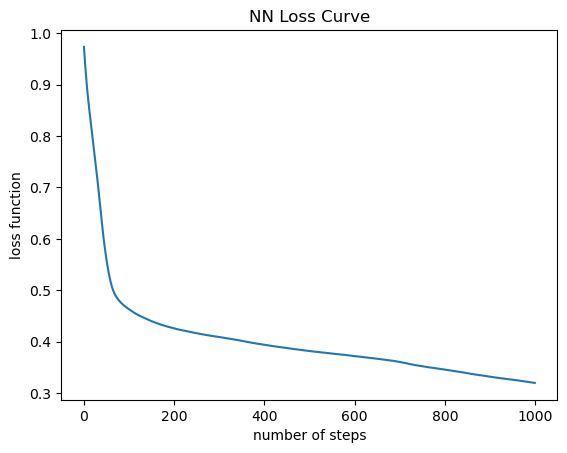

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(mlp.loss_curve_)
plt.title("NN Loss Curve")
plt.xlabel("number of steps")
plt.ylabel("loss function")
plt.show()

In [9]:
mlp.intercepts_[0]

array([-0.73789541,  0.19114027, -0.48111694,  0.22361436,  0.65651171,
       -0.45474338, -0.54173307,  0.57064626,  0.54775614,  0.82921315])

In [10]:
mlp.coefs_[0]

array([[-0.73573392,  0.66128634, -0.78235156,  0.17314407,  0.56630318,
        -0.04745308,  0.1541847 , -0.84996535, -0.27455765, -0.31934634],
       [-0.16934322,  0.45350596, -0.22837276, -0.48795453, -0.20501971,
         0.93258063, -0.05062183,  0.1248382 ,  0.83068277, -0.37446488],
       [-0.26183688,  0.23212921,  0.0786913 ,  0.45696004, -0.12769152,
        -0.30026327,  0.6870468 ,  0.09727278, -0.46978622,  0.10866209],
       [-0.55121076,  0.21640212,  0.04549597, -0.18711704,  0.17419767,
        -0.34648717,  0.39765556, -0.50946379,  0.14555434,  0.16947169],
       [ 0.0894359 , -0.27538532,  0.35227155,  0.22268251, -0.37159788,
         0.3810828 , -0.1610418 ,  0.62813312, -0.51018817,  0.05251514],
       [-0.24926178, -0.0901546 ,  0.58051514,  0.04252584, -0.29214173,
        -0.97597617, -0.44887814, -0.09461574,  0.53102923,  0.04457461],
       [ 0.56841192,  0.3113257 , -0.75733597, -0.17069777, -0.24707364,
        -0.1733464 ,  0.78796791,  0.0904021 

## MLP using keras

In [11]:
from keras.models import Sequential
from keras.layers import Dense


# create keras model
model = Sequential()
model.add(Dense(12, input_dim=8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))

print(model.summary())

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 12)                108       


 dense_1 (Dense)             (None, 8)                 104       


 dense_2 (Dense)             (None, 1)                 9         


Total params: 221 (884.00 Byte)


Trainable params: 221 (884.00 Byte)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


None


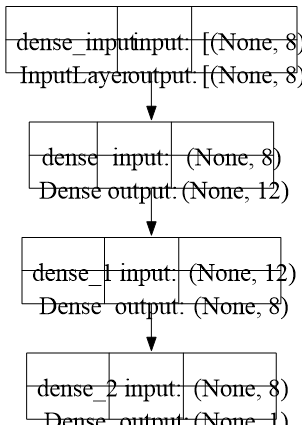

In [12]:
import os
import shutil
import sys
from IPython.display import Image, display
from keras.utils import plot_model

graphviz_bin = os.path.join(sys.prefix, 'Library', 'bin')
if os.path.isdir(graphviz_bin):
    os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ.get('PATH', '')

if shutil.which('dot') is None:
    print("Graphviz 'dot' was not found; skipping the optional model diagram.")
else:
    try:
        plot_model(model, to_file='model.png', show_shapes=True)
        display(Image(filename='model.png'))
    except (ImportError, OSError) as error:
        print(f"Could not create the optional model diagram: {error}")

In [13]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Fit the model

history=model.fit(X_train, y_train, validation_split=0.25, epochs=80, batch_size=10)
# calculate predictions

Epoch 1/80


 1/39 [..............................] - ETA: 38s - loss: 0.6931 - acc: 0.6000

31/39 [======================>.......] - ETA: 0s - loss: 0.6906 - acc: 0.6645 

39/39 [==============================] - 1s 8ms/step - loss: 0.6898 - acc: 0.6641 - val_loss: 0.6873 - val_acc: 0.6172


Epoch 2/80


 1/39 [..............................] - ETA: 0s - loss: 0.6886 - acc: 0.6000

33/39 [========================>.....] - ETA: 0s - loss: 0.6791 - acc: 0.6515

39/39 [==============================] - 0s 3ms/step - loss: 0.6764 - acc: 0.6615 - val_loss: 0.6692 - val_acc: 0.6172


Epoch 3/80


 1/39 [..............................] - ETA: 0s - loss: 0.6461 - acc: 0.8000

35/39 [=========================>....] - ETA: 0s - loss: 0.6423 - acc: 0.6543

39/39 [==============================] - 0s 3ms/step - loss: 0.6379 - acc: 0.6615 - val_loss: 0.6246 - val_acc: 0.6172


Epoch 4/80


 1/39 [..............................] - ETA: 0s - loss: 0.7059 - acc: 0.5000

34/39 [=========================>....] - ETA: 0s - loss: 0.5678 - acc: 0.6765

39/39 [==============================] - 0s 3ms/step - loss: 0.5752 - acc: 0.6615 - val_loss: 0.5781 - val_acc: 0.6172


Epoch 5/80


 1/39 [..............................] - ETA: 0s - loss: 0.4942 - acc: 0.8000

39/39 [==============================] - 0s 3ms/step - loss: 0.5295 - acc: 0.6589 - val_loss: 0.5611 - val_acc: 0.6484


Epoch 6/80


 1/39 [..............................] - ETA: 0s - loss: 0.3441 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.5115 - acc: 0.7289

39/39 [==============================] - 0s 3ms/step - loss: 0.5090 - acc: 0.7318 - val_loss: 0.5493 - val_acc: 0.7422


Epoch 7/80


 1/39 [..............................] - ETA: 0s - loss: 0.5337 - acc: 0.7000

37/39 [===========================>..] - ETA: 0s - loss: 0.5024 - acc: 0.7892

39/39 [==============================] - 0s 3ms/step - loss: 0.5000 - acc: 0.7917 - val_loss: 0.5407 - val_acc: 0.7422


Epoch 8/80


 1/39 [..............................] - ETA: 0s - loss: 0.6548 - acc: 0.6000

39/39 [==============================] - ETA: 0s - loss: 0.4905 - acc: 0.7917

39/39 [==============================] - 0s 3ms/step - loss: 0.4905 - acc: 0.7917 - val_loss: 0.5334 - val_acc: 0.7500


Epoch 9/80


 1/39 [..............................] - ETA: 0s - loss: 0.4422 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4813 - acc: 0.7946

39/39 [==============================] - 0s 3ms/step - loss: 0.4856 - acc: 0.7917 - val_loss: 0.5289 - val_acc: 0.7500


Epoch 10/80


 1/39 [..............................] - ETA: 0s - loss: 0.3761 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4767 - acc: 0.7921

39/39 [==============================] - 0s 3ms/step - loss: 0.4784 - acc: 0.7917 - val_loss: 0.5170 - val_acc: 0.7734


Epoch 11/80


 1/39 [..............................] - ETA: 0s - loss: 0.3973 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4720 - acc: 0.7917

39/39 [==============================] - 0s 3ms/step - loss: 0.4720 - acc: 0.7917 - val_loss: 0.5112 - val_acc: 0.7812


Epoch 12/80


 1/39 [..............................] - ETA: 0s - loss: 0.2763 - acc: 0.9000

39/39 [==============================] - 0s 2ms/step - loss: 0.4671 - acc: 0.7891 - val_loss: 0.5072 - val_acc: 0.7891


Epoch 13/80


 1/39 [..............................] - ETA: 0s - loss: 0.3656 - acc: 0.9000

39/39 [==============================] - 0s 3ms/step - loss: 0.4616 - acc: 0.7917 - val_loss: 0.4999 - val_acc: 0.7812


Epoch 14/80


 1/39 [..............................] - ETA: 0s - loss: 0.4017 - acc: 0.8000

39/39 [==============================] - 0s 2ms/step - loss: 0.4582 - acc: 0.7839 - val_loss: 0.4973 - val_acc: 0.7812


Epoch 15/80


 1/39 [..............................] - ETA: 0s - loss: 0.6774 - acc: 0.8000

39/39 [==============================] - 0s 2ms/step - loss: 0.4556 - acc: 0.7865 - val_loss: 0.4927 - val_acc: 0.7812


Epoch 16/80


 1/39 [..............................] - ETA: 0s - loss: 0.3895 - acc: 0.8000

39/39 [==============================] - 0s 2ms/step - loss: 0.4531 - acc: 0.7839 - val_loss: 0.4940 - val_acc: 0.7812


Epoch 17/80


 1/39 [..............................] - ETA: 0s - loss: 0.7533 - acc: 0.5000

39/39 [==============================] - 0s 3ms/step - loss: 0.4514 - acc: 0.7865 - val_loss: 0.4953 - val_acc: 0.7812


Epoch 18/80


 1/39 [..............................] - ETA: 0s - loss: 0.6149 - acc: 0.7000

34/39 [=========================>....] - ETA: 0s - loss: 0.4515 - acc: 0.7853

39/39 [==============================] - 0s 3ms/step - loss: 0.4497 - acc: 0.7865 - val_loss: 0.4881 - val_acc: 0.7812


Epoch 19/80


 1/39 [..............................] - ETA: 0s - loss: 0.4546 - acc: 0.7000

38/39 [============================>.] - ETA: 0s - loss: 0.4481 - acc: 0.7868

39/39 [==============================] - 0s 3ms/step - loss: 0.4486 - acc: 0.7865 - val_loss: 0.4920 - val_acc: 0.7891


Epoch 20/80


 1/39 [..............................] - ETA: 0s - loss: 0.5227 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4481 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4481 - acc: 0.7891 - val_loss: 0.4880 - val_acc: 0.7812


Epoch 21/80


 1/39 [..............................] - ETA: 0s - loss: 0.3519 - acc: 0.9000

37/39 [===========================>..] - ETA: 0s - loss: 0.4541 - acc: 0.7784

39/39 [==============================] - 0s 3ms/step - loss: 0.4470 - acc: 0.7865 - val_loss: 0.4872 - val_acc: 0.7734


Epoch 22/80


 1/39 [..............................] - ETA: 0s - loss: 0.4022 - acc: 0.7000

38/39 [============================>.] - ETA: 0s - loss: 0.4470 - acc: 0.7816

39/39 [==============================] - 0s 3ms/step - loss: 0.4455 - acc: 0.7839 - val_loss: 0.4869 - val_acc: 0.7734


Epoch 23/80


 1/39 [..............................] - ETA: 0s - loss: 0.3413 - acc: 0.9000

39/39 [==============================] - ETA: 0s - loss: 0.4454 - acc: 0.7865

39/39 [==============================] - 0s 3ms/step - loss: 0.4454 - acc: 0.7865 - val_loss: 0.4892 - val_acc: 0.7734


Epoch 24/80


 1/39 [..............................] - ETA: 0s - loss: 0.2500 - acc: 0.9000

39/39 [==============================] - ETA: 0s - loss: 0.4448 - acc: 0.7865

39/39 [==============================] - 0s 3ms/step - loss: 0.4448 - acc: 0.7865 - val_loss: 0.4878 - val_acc: 0.7812


Epoch 25/80


 1/39 [..............................] - ETA: 0s - loss: 0.2032 - acc: 1.0000

37/39 [===========================>..] - ETA: 0s - loss: 0.4473 - acc: 0.7811

39/39 [==============================] - 0s 3ms/step - loss: 0.4442 - acc: 0.7839 - val_loss: 0.4882 - val_acc: 0.7734


Epoch 26/80


 1/39 [..............................] - ETA: 0s - loss: 0.6497 - acc: 0.7000

39/39 [==============================] - ETA: 0s - loss: 0.4432 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4432 - acc: 0.7891 - val_loss: 0.4869 - val_acc: 0.7734


Epoch 27/80


 1/39 [..............................] - ETA: 0s - loss: 0.3610 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4379 - acc: 0.7919

39/39 [==============================] - 0s 3ms/step - loss: 0.4431 - acc: 0.7865 - val_loss: 0.4885 - val_acc: 0.7734


Epoch 28/80


 1/39 [..............................] - ETA: 0s - loss: 0.3393 - acc: 0.9000

39/39 [==============================] - ETA: 0s - loss: 0.4429 - acc: 0.7865

39/39 [==============================] - 0s 3ms/step - loss: 0.4429 - acc: 0.7865 - val_loss: 0.4879 - val_acc: 0.7734


Epoch 29/80


 1/39 [..............................] - ETA: 0s - loss: 0.8750 - acc: 0.6000

38/39 [============================>.] - ETA: 0s - loss: 0.4409 - acc: 0.7921

39/39 [==============================] - 0s 3ms/step - loss: 0.4420 - acc: 0.7891 - val_loss: 0.4871 - val_acc: 0.7812


Epoch 30/80


 1/39 [..............................] - ETA: 0s - loss: 0.3066 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4422 - acc: 0.7865

39/39 [==============================] - 0s 3ms/step - loss: 0.4422 - acc: 0.7865 - val_loss: 0.4878 - val_acc: 0.7734


Epoch 31/80


 1/39 [..............................] - ETA: 0s - loss: 0.5076 - acc: 0.7000

37/39 [===========================>..] - ETA: 0s - loss: 0.4423 - acc: 0.7919

39/39 [==============================] - 0s 3ms/step - loss: 0.4413 - acc: 0.7891 - val_loss: 0.4906 - val_acc: 0.7734


Epoch 32/80


 1/39 [..............................] - ETA: 0s - loss: 0.2925 - acc: 0.9000

36/39 [==========================>...] - ETA: 0s - loss: 0.4347 - acc: 0.7917

39/39 [==============================] - 0s 3ms/step - loss: 0.4410 - acc: 0.7865 - val_loss: 0.4899 - val_acc: 0.7734


Epoch 33/80


 1/39 [..............................] - ETA: 0s - loss: 0.2527 - acc: 1.0000

38/39 [============================>.] - ETA: 0s - loss: 0.4415 - acc: 0.7895

39/39 [==============================] - 0s 3ms/step - loss: 0.4413 - acc: 0.7891 - val_loss: 0.4872 - val_acc: 0.7734


Epoch 34/80


 1/39 [..............................] - ETA: 0s - loss: 0.3784 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4401 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4401 - acc: 0.7891 - val_loss: 0.4894 - val_acc: 0.7734


Epoch 35/80


 1/39 [..............................] - ETA: 0s - loss: 0.3119 - acc: 0.9000

38/39 [============================>.] - ETA: 0s - loss: 0.4365 - acc: 0.7921

39/39 [==============================] - 0s 3ms/step - loss: 0.4408 - acc: 0.7891 - val_loss: 0.4918 - val_acc: 0.7734


Epoch 36/80


 1/39 [..............................] - ETA: 0s - loss: 0.6522 - acc: 0.7000

39/39 [==============================] - ETA: 0s - loss: 0.4398 - acc: 0.7865

39/39 [==============================] - 0s 3ms/step - loss: 0.4398 - acc: 0.7865 - val_loss: 0.4913 - val_acc: 0.7734


Epoch 37/80


 1/39 [..............................] - ETA: 0s - loss: 0.4804 - acc: 0.7000

38/39 [============================>.] - ETA: 0s - loss: 0.4405 - acc: 0.7868

39/39 [==============================] - 0s 3ms/step - loss: 0.4396 - acc: 0.7865 - val_loss: 0.4969 - val_acc: 0.7656


Epoch 38/80


 1/39 [..............................] - ETA: 0s - loss: 0.8378 - acc: 0.6000

39/39 [==============================] - 0s 2ms/step - loss: 0.4405 - acc: 0.7891 - val_loss: 0.4948 - val_acc: 0.7656


Epoch 39/80


 1/39 [..............................] - ETA: 0s - loss: 0.2392 - acc: 0.9000

39/39 [==============================] - ETA: 0s - loss: 0.4392 - acc: 0.7839

39/39 [==============================] - 0s 3ms/step - loss: 0.4392 - acc: 0.7839 - val_loss: 0.4925 - val_acc: 0.7656


Epoch 40/80


 1/39 [..............................] - ETA: 0s - loss: 0.4115 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4396 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4396 - acc: 0.7891 - val_loss: 0.4954 - val_acc: 0.7656


Epoch 41/80


 1/39 [..............................] - ETA: 0s - loss: 0.4649 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4411 - acc: 0.7947

39/39 [==============================] - 0s 3ms/step - loss: 0.4406 - acc: 0.7969 - val_loss: 0.4918 - val_acc: 0.7656


Epoch 42/80


 1/39 [..............................] - ETA: 0s - loss: 0.6239 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4377 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4377 - acc: 0.7891 - val_loss: 0.4978 - val_acc: 0.7656


Epoch 43/80


 1/39 [..............................] - ETA: 0s - loss: 0.9763 - acc: 0.4000

39/39 [==============================] - 0s 3ms/step - loss: 0.4386 - acc: 0.7891 - val_loss: 0.4941 - val_acc: 0.7734


Epoch 44/80


 1/39 [..............................] - ETA: 0s - loss: 0.9645 - acc: 0.4000

37/39 [===========================>..] - ETA: 0s - loss: 0.4351 - acc: 0.7919

39/39 [==============================] - 0s 3ms/step - loss: 0.4372 - acc: 0.7891 - val_loss: 0.4973 - val_acc: 0.7656


Epoch 45/80


 1/39 [..............................] - ETA: 0s - loss: 0.2586 - acc: 0.9000

39/39 [==============================] - ETA: 0s - loss: 0.4369 - acc: 0.7917

39/39 [==============================] - 0s 3ms/step - loss: 0.4369 - acc: 0.7917 - val_loss: 0.4946 - val_acc: 0.7734


Epoch 46/80


 1/39 [..............................] - ETA: 0s - loss: 0.3542 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4372 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4372 - acc: 0.7891 - val_loss: 0.4941 - val_acc: 0.7734


Epoch 47/80


 1/39 [..............................] - ETA: 0s - loss: 0.1613 - acc: 1.0000

39/39 [==============================] - ETA: 0s - loss: 0.4367 - acc: 0.7917

39/39 [==============================] - 0s 3ms/step - loss: 0.4367 - acc: 0.7917 - val_loss: 0.4932 - val_acc: 0.7734


Epoch 48/80


 1/39 [..............................] - ETA: 0s - loss: 0.6023 - acc: 0.8000

35/39 [=========================>....] - ETA: 0s - loss: 0.4406 - acc: 0.7886

39/39 [==============================] - 0s 3ms/step - loss: 0.4360 - acc: 0.7891 - val_loss: 0.4941 - val_acc: 0.7734


Epoch 49/80


 1/39 [..............................] - ETA: 0s - loss: 0.4536 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4331 - acc: 0.7921

39/39 [==============================] - 0s 3ms/step - loss: 0.4367 - acc: 0.7891 - val_loss: 0.4931 - val_acc: 0.7812


Epoch 50/80


 1/39 [..............................] - ETA: 0s - loss: 0.2535 - acc: 0.9000

37/39 [===========================>..] - ETA: 0s - loss: 0.4289 - acc: 0.7946

39/39 [==============================] - 0s 3ms/step - loss: 0.4359 - acc: 0.7865 - val_loss: 0.4976 - val_acc: 0.7734


Epoch 51/80


 1/39 [..............................] - ETA: 0s - loss: 0.8614 - acc: 0.5000

37/39 [===========================>..] - ETA: 0s - loss: 0.4221 - acc: 0.7973

39/39 [==============================] - 0s 3ms/step - loss: 0.4358 - acc: 0.7917 - val_loss: 0.4981 - val_acc: 0.7734


Epoch 52/80


 1/39 [..............................] - ETA: 0s - loss: 0.3357 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4354 - acc: 0.7891

39/39 [==============================] - 0s 3ms/step - loss: 0.4354 - acc: 0.7891 - val_loss: 0.4933 - val_acc: 0.7812


Epoch 53/80


 1/39 [..............................] - ETA: 0s - loss: 0.5122 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4388 - acc: 0.7919

39/39 [==============================] - 0s 3ms/step - loss: 0.4355 - acc: 0.7943 - val_loss: 0.4965 - val_acc: 0.7734


Epoch 54/80


 1/39 [..............................] - ETA: 0s - loss: 0.4756 - acc: 0.7000

39/39 [==============================] - 0s 3ms/step - loss: 0.4350 - acc: 0.7943 - val_loss: 0.4985 - val_acc: 0.7734


Epoch 55/80


 1/39 [..............................] - ETA: 0s - loss: 0.2759 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4381 - acc: 0.7892

39/39 [==============================] - 0s 3ms/step - loss: 0.4347 - acc: 0.7943 - val_loss: 0.4922 - val_acc: 0.7812


Epoch 56/80


 1/39 [..............................] - ETA: 0s - loss: 0.4115 - acc: 0.9000

37/39 [===========================>..] - ETA: 0s - loss: 0.4307 - acc: 0.7946

39/39 [==============================] - 0s 3ms/step - loss: 0.4344 - acc: 0.7969 - val_loss: 0.4949 - val_acc: 0.7812


Epoch 57/80


 1/39 [..............................] - ETA: 0s - loss: 0.2992 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4341 - acc: 0.7947

39/39 [==============================] - 0s 3ms/step - loss: 0.4343 - acc: 0.7917 - val_loss: 0.4928 - val_acc: 0.7734


Epoch 58/80


 1/39 [..............................] - ETA: 0s - loss: 0.4195 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4350 - acc: 0.7974

39/39 [==============================] - 0s 3ms/step - loss: 0.4339 - acc: 0.7969 - val_loss: 0.4940 - val_acc: 0.7734


Epoch 59/80


 1/39 [..............................] - ETA: 0s - loss: 0.2185 - acc: 0.9000

38/39 [============================>.] - ETA: 0s - loss: 0.4335 - acc: 0.7974

39/39 [==============================] - 0s 3ms/step - loss: 0.4353 - acc: 0.7969 - val_loss: 0.4972 - val_acc: 0.7734


Epoch 60/80


 1/39 [..............................] - ETA: 0s - loss: 0.2708 - acc: 0.9000

38/39 [============================>.] - ETA: 0s - loss: 0.4346 - acc: 0.7947

39/39 [==============================] - 0s 3ms/step - loss: 0.4339 - acc: 0.7943 - val_loss: 0.5010 - val_acc: 0.7734


Epoch 61/80


 1/39 [..............................] - ETA: 0s - loss: 0.2535 - acc: 1.0000

39/39 [==============================] - 0s 3ms/step - loss: 0.4326 - acc: 0.7917 - val_loss: 0.4963 - val_acc: 0.7812


Epoch 62/80


 1/39 [..............................] - ETA: 0s - loss: 0.6101 - acc: 0.6000

39/39 [==============================] - 0s 3ms/step - loss: 0.4331 - acc: 0.7891 - val_loss: 0.4981 - val_acc: 0.7734


Epoch 63/80


 1/39 [..............................] - ETA: 0s - loss: 0.5457 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4355 - acc: 0.7973

39/39 [==============================] - 0s 3ms/step - loss: 0.4324 - acc: 0.7969 - val_loss: 0.4980 - val_acc: 0.7734


Epoch 64/80


 1/39 [..............................] - ETA: 0s - loss: 0.4300 - acc: 0.9000

39/39 [==============================] - 0s 3ms/step - loss: 0.4320 - acc: 0.7917 - val_loss: 0.4973 - val_acc: 0.7812


Epoch 65/80


 1/39 [..............................] - ETA: 0s - loss: 0.4060 - acc: 0.7000

39/39 [==============================] - 0s 2ms/step - loss: 0.4318 - acc: 0.7891 - val_loss: 0.5012 - val_acc: 0.7734


Epoch 66/80


 1/39 [..............................] - ETA: 0s - loss: 0.3273 - acc: 0.9000

34/39 [=========================>....] - ETA: 0s - loss: 0.4303 - acc: 0.8000

39/39 [==============================] - 0s 3ms/step - loss: 0.4324 - acc: 0.7917 - val_loss: 0.4958 - val_acc: 0.7812


Epoch 67/80


 1/39 [..............................] - ETA: 0s - loss: 0.1548 - acc: 1.0000

39/39 [==============================] - 0s 3ms/step - loss: 0.4311 - acc: 0.7943 - val_loss: 0.4996 - val_acc: 0.7734


Epoch 68/80


 1/39 [..............................] - ETA: 0s - loss: 0.7880 - acc: 0.5000

39/39 [==============================] - 0s 3ms/step - loss: 0.4319 - acc: 0.7969 - val_loss: 0.4993 - val_acc: 0.7812


Epoch 69/80


 1/39 [..............................] - ETA: 0s - loss: 0.3853 - acc: 0.8000

39/39 [==============================] - 0s 3ms/step - loss: 0.4306 - acc: 0.7943 - val_loss: 0.4954 - val_acc: 0.7812


Epoch 70/80


 1/39 [..............................] - ETA: 0s - loss: 0.4740 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4358 - acc: 0.8000

39/39 [==============================] - 0s 3ms/step - loss: 0.4304 - acc: 0.8021 - val_loss: 0.4990 - val_acc: 0.7734


Epoch 71/80


 1/39 [..............................] - ETA: 0s - loss: 0.3199 - acc: 0.8000

39/39 [==============================] - ETA: 0s - loss: 0.4298 - acc: 0.7995

39/39 [==============================] - 0s 3ms/step - loss: 0.4298 - acc: 0.7995 - val_loss: 0.5009 - val_acc: 0.7734


Epoch 72/80


 1/39 [..............................] - ETA: 0s - loss: 0.9919 - acc: 0.5000

38/39 [============================>.] - ETA: 0s - loss: 0.4291 - acc: 0.8000

39/39 [==============================] - 0s 3ms/step - loss: 0.4292 - acc: 0.7995 - val_loss: 0.5012 - val_acc: 0.7734


Epoch 73/80


 1/39 [..............................] - ETA: 0s - loss: 0.4624 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4328 - acc: 0.7947

39/39 [==============================] - 0s 3ms/step - loss: 0.4296 - acc: 0.7969 - val_loss: 0.4998 - val_acc: 0.7734


Epoch 74/80


 1/39 [..............................] - ETA: 0s - loss: 0.4930 - acc: 0.9000

38/39 [============================>.] - ETA: 0s - loss: 0.4317 - acc: 0.7947

39/39 [==============================] - 0s 3ms/step - loss: 0.4291 - acc: 0.7969 - val_loss: 0.4999 - val_acc: 0.7734


Epoch 75/80


 1/39 [..............................] - ETA: 0s - loss: 0.2660 - acc: 0.9000

39/39 [==============================] - 0s 3ms/step - loss: 0.4294 - acc: 0.7995 - val_loss: 0.5052 - val_acc: 0.7656


Epoch 76/80


 1/39 [..............................] - ETA: 0s - loss: 0.4597 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4312 - acc: 0.8000

39/39 [==============================] - 0s 3ms/step - loss: 0.4283 - acc: 0.7995 - val_loss: 0.5012 - val_acc: 0.7734


Epoch 77/80


 1/39 [..............................] - ETA: 0s - loss: 0.6040 - acc: 0.8000

38/39 [============================>.] - ETA: 0s - loss: 0.4321 - acc: 0.7947

39/39 [==============================] - 0s 3ms/step - loss: 0.4285 - acc: 0.7969 - val_loss: 0.5033 - val_acc: 0.7734


Epoch 78/80


 1/39 [..............................] - ETA: 0s - loss: 0.5448 - acc: 0.7000

38/39 [============================>.] - ETA: 0s - loss: 0.4194 - acc: 0.7974

39/39 [==============================] - 0s 3ms/step - loss: 0.4288 - acc: 0.7943 - val_loss: 0.5057 - val_acc: 0.7734


Epoch 79/80


 1/39 [..............................] - ETA: 0s - loss: 0.3099 - acc: 0.9000

39/39 [==============================] - 0s 3ms/step - loss: 0.4285 - acc: 0.7995 - val_loss: 0.4997 - val_acc: 0.7734


Epoch 80/80


 1/39 [..............................] - ETA: 0s - loss: 0.2999 - acc: 0.8000

37/39 [===========================>..] - ETA: 0s - loss: 0.4247 - acc: 0.8027

39/39 [==============================] - 0s 3ms/step - loss: 0.4286 - acc: 0.8021 - val_loss: 0.5013 - val_acc: 0.7734


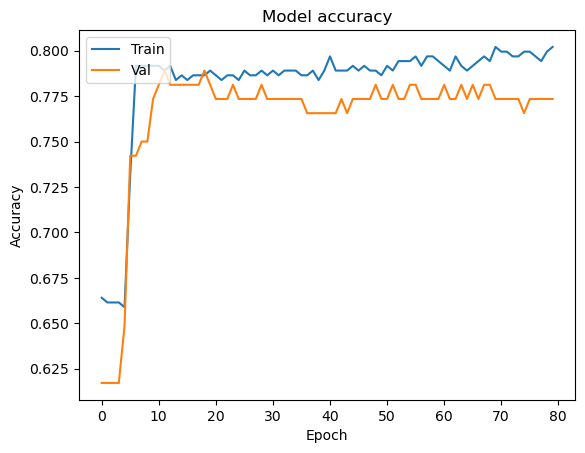

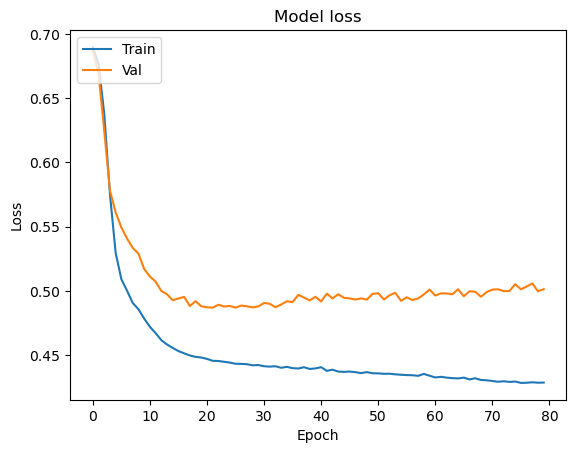

In [14]:
# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [15]:
for layer in model.layers:
    weights = layer.get_weights()
    print(weights)

[array([[ 0.03980516,  0.31657228, -0.09990724,  0.08006705,  0.14035913,
         0.10677772, -0.17991695,  0.29879054, -0.16008498, -0.04051206,
        -0.22699513, -0.04653285],
       [-0.21583831,  0.44595644, -0.10792643,  0.43857312, -0.2639552 ,
        -0.26853666, -0.1405265 ,  0.45830378, -0.2524519 , -0.31974614,
        -0.05343337, -0.12883414],
       [-0.10023105, -0.01698898,  0.10854774, -0.16665775, -0.16840751,
        -0.13209347,  0.24083982, -0.22284448,  0.16187935,  0.10224693,
         0.20428719,  0.2133231 ],
       [-0.16714282,  0.07256874,  0.04047598, -0.13526154, -0.14315026,
        -0.2224625 , -0.02252468, -0.06100773, -0.02985683,  0.04023369,
         0.12522069, -0.01335599],
       [ 0.14562272,  0.04875682, -0.3045748 , -0.0704065 ,  0.02058206,
         0.13049233, -0.09633546, -0.11902674, -0.09250293,  0.12189572,
        -0.09128892, -0.2124456 ],
       [-0.29036945,  0.24918017, -0.02812237,  0.2951887 , -0.12589994,
        -0.06628928, 

In [16]:
predictions = model.predict(X_test)
p_labels = [round(x[0]) for x in predictions]


1/8 [==>...........................] - ETA: 0s

8/8 [==============================] - 0s 1ms/step


In [17]:
p_labels

[0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [18]:
print("Accuracy", metrics.accuracy_score(y_test, p_labels))
print(confusion_matrix(y_test,p_labels))
print(classification_report(y_test,p_labels))

Accuracy 0.7421875
[[143  24]
 [ 42  47]]
              precision    recall  f1-score   support

         0.0       0.77      0.86      0.81       167
         1.0       0.66      0.53      0.59        89

    accuracy                           0.74       256
   macro avg       0.72      0.69      0.70       256
weighted avg       0.73      0.74      0.73       256



## Comparing MLP architectures

In this section, several Keras MLP architectures are compared on the diabetes dataset. The same training/test split, standardised inputs, optimiser, batch size, and 40 training epochs are used for every model, so the main experimental variable is the network architecture. The models range from a linear classifier to shallow, wider, and deeper networks. Test accuracy and the precision, recall, and F1-score of the diabetes class (class 1) are recorded.

In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

architectures = {
    'linear (8-1)': (),
    'tiny (8-4-1)': (4,),
    'small (8-8-1)': (8,),
    'baseline (8-12-8-1)': (12, 8),
    'wide (8-16-1)': (16,),
    'wider (8-24-1)': (24,),
    'deep (8-8-8-1)': (8, 8),
    'larger-deep (8-32-16-1)': (32, 16),
}

experiment_results = []
experiment_models = {}
for name, hidden_layers in architectures.items():
    experiment_model = Sequential()
    if hidden_layers:
        experiment_model.add(Dense(hidden_layers[0], input_dim=8, activation='relu', kernel_initializer='uniform'))
        for units in hidden_layers[1:]:
            experiment_model.add(Dense(units, activation='relu', kernel_initializer='uniform'))
    else:
        experiment_model.add(Dense(1, input_dim=8, activation='sigmoid', kernel_initializer='uniform'))
    experiment_model.add(Dense(1, activation='sigmoid', kernel_initializer='uniform'))
    experiment_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    experiment_model.fit(X_train, y_train, validation_split=0.25, epochs=40, batch_size=10, verbose=0)
    probabilities = experiment_model.predict(X_test, verbose=0).ravel()
    labels = (probabilities >= 0.5).astype(int)
    experiment_results.append({
        'architecture': name,
        'accuracy': accuracy_score(y_test, labels),
        'precision (class 1)': precision_score(y_test, labels, zero_division=0),
        'recall (class 1)': recall_score(y_test, labels, zero_division=0),
        'f1 (class 1)': f1_score(y_test, labels, zero_division=0),
    })
    experiment_models[name] = experiment_model

results_df = pd.DataFrame(experiment_results).sort_values('accuracy', ascending=False)
results_df.round(3)

,architecture,accuracy,precision (class 1),recall (class 1),f1 (class 1)
1,tiny (8-4-1),0.758,0.680,0.573,0.622
6,deep (8-8-8-1),0.758,0.685,0.562,0.617
2,small (8-8-1),0.750,0.671,0.551,0.605
3,baseline (8-12-8-1),0.750,0.676,0.539,0.600
4,wide (8-16-1),0.742,0.662,0.528,0.588
5,wider (8-24-1),0.738,0.657,0.517,0.579
7,larger-deep (8-32-16-1),0.738,0.653,0.528,0.584
0,linear (8-1),0.652,0.000,0.000,0.000


### Experiment notes

The tiny architecture (8-4-1) achieved the best overall result in this run, with an accuracy of 0.758 and the highest class 1 recall (0.573) and F1-score (0.622). The deep architecture (8-8-8-1) achieved the same accuracy, but its recall and F1-score were slightly lower. The small and baseline architectures performed reasonably well, while increasing the width to 16 or 24 hidden units, or using the larger deep architecture, did not improve generalisation. This suggests that the dataset does not require a highly complex network and that additional parameters may increase variability or overfitting without adding useful predictive power. The linear model was substantially weaker, with an accuracy of 0.652 and no correctly predicted class 1 cases in this run, indicating that nonlinear hidden layers are important for this task. Because neural-network weights are randomly initialised, the exact metrics may vary slightly between runs; the model should therefore be selected using the trade-off between accuracy, class 1 recall, and F1-score rather than accuracy alone.